<a href="https://colab.research.google.com/github/amrut23ds48/ml/blob/main/ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
data_size = 200

age = np.random.randint(18, 60, size=data_size)
steps = np.random.randint(2000, 15000, size=data_size)
sleep = np.random.uniform(5, 9, size=data_size)

# 2. Creating a Relationship (The "Secret" Formula)
# Calories = (Steps * 0.15) + (Age * -2) + (Sleep * 50) + Base_Metabolism + Noise
noise = np.random.normal(0, 50, size=data_size)
calories = (steps * 0.12) - (age * 1.5) + (sleep * 40) + 1200 + noise

# 3. Creating a Logical Category (Classification)
# If steps > 10000 -> Elite, > 5000 -> Active, else Sedentary
fitness_cat = []
for s in steps:
    if s > 10000: fitness_cat.append('Elite')
    elif s > 5000: fitness_cat.append('Active')
    else: fitness_cat.append('Sedentary')

df = pd.DataFrame({
    'Age': age,
    'Daily_Steps': steps,
    'Sleep_Hours': sleep.round(1),
    'Calories_Burned': calories.astype(int),
    'Fitness_Category': fitness_cat
})

df.to_csv('smart_fitness_data.csv', index=False)

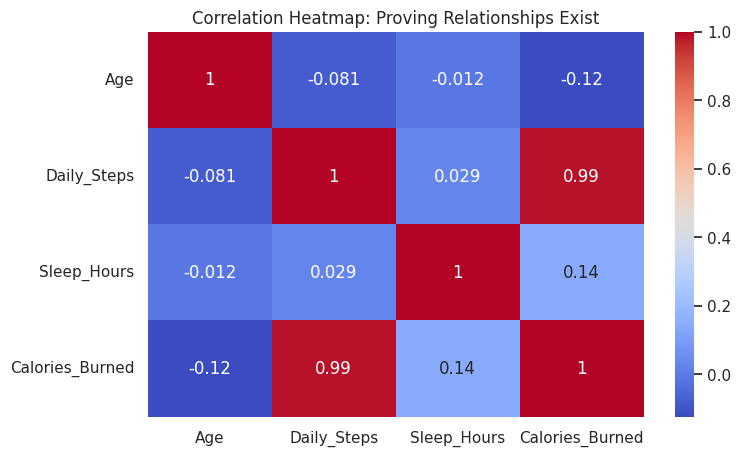

In [ ]:
#2 introduction to libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('smart_fitness_data.csv')

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap: Proving Relationships Exist")
plt.show()

Model Coefficient (Slope): 0.1219
Model Intercept: 1408.5218
Mean Squared Error: 6590.46
R2 Score (Accuracy): 0.9706


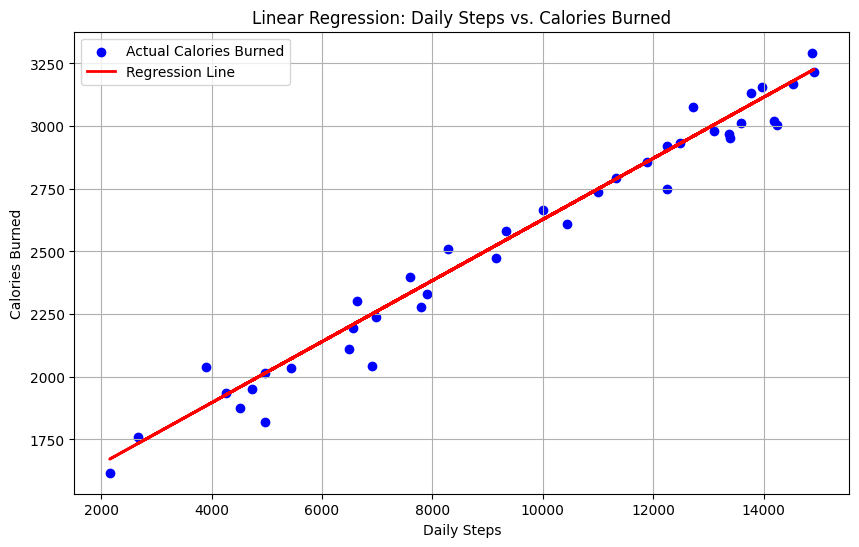

In [ ]:
#3 linear
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('smart_fitness_data.csv')

X = df[['Daily_Steps']]
y = df['Calories_Burned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Model Intercept: {model.intercept_:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score (Accuracy): {r2:.4f}")

# Plotting the regression
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Calories Burned')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Daily Steps')
plt.ylabel('Calories Burned')
plt.title('Linear Regression: Daily Steps vs. Calories Burned')
plt.legend()
plt.grid(True)
plt.show()

Accuracy:  0.97
Precision: 0.95 (When it predicts Elite, how often is it right?)
Recall:    1.00 (How many of the actual Elite users did it catch?)
F1 Score:  0.97 (Balance between Precision and Recall)

Full Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.95      1.00      0.97        19

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



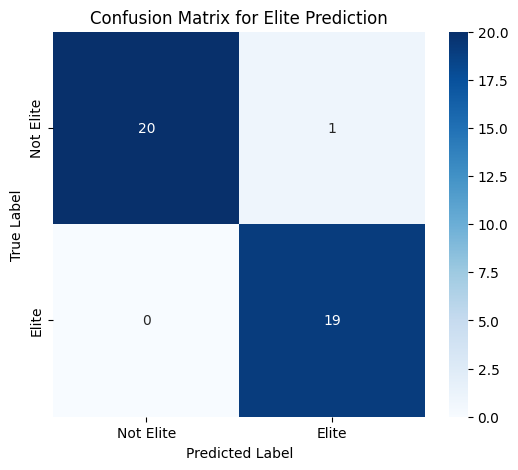

In [ ]:
#4 logistic
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

df = pd.read_csv('smart_fitness_data.csv')

df['Is_Elite'] = (df['Fitness_Category'] == 'Elite').astype(int)

X = df[['Daily_Steps', 'Age']]
y = df['Is_Elite']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f} (When it predicts Elite, how often is it right?)")
print(f"Recall:    {recall:.2f} (How many of the actual Elite users did it catch?)")
print(f"F1 Score:  {f1:.2f} (Balance between Precision and Recall)")
print("\nFull Classification Report:\n", classification_report(y_test, y_pred))

# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Elite', 'Elite'], yticklabels=['Not Elite', 'Elite'])
plt.title('Confusion Matrix for Elite Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
#5 svm
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('smart_fitness_data.csv')


X = df[['Daily_Steps', 'Age', 'Sleep_Hours']]
y = df['Fitness_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

print(f"SVM Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

SVM Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

      Active       0.92      0.92      0.92        13
       Elite       0.95      1.00      0.97        19
   Sedentary       1.00      0.88      0.93         8

    accuracy                           0.95        40
   macro avg       0.96      0.93      0.94        40
weighted avg       0.95      0.95      0.95        40



In [ ]:
#6 hebbian
import numpy as np

X = np.array([
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

y = np.array([0, 0, 0, 1])

w = np.zeros(3)
eta = 0.1

for i in range(len(X)):
    # The core rule: w = w + learning_rate * input * output
    w = w + eta * X[i] * y[i]

print("Trained weights (bias, w1, w2):", w)

# Test
print("\nTesting AND gate:")
for i in range(len(X)):
    out = np.dot(X[i], w)
    print(f"Input: {X[i,1:]} -> Weighted sum: {out:.2f} -> Binary: {1 if out > 0.5 else 0}")

Trained weights (bias, w1, w2): [0.1 0.1 0.1]

Testing AND gate:
Input: [0 0] -> Weighted sum: 0.10 -> Binary: 0
Input: [0 1] -> Weighted sum: 0.20 -> Binary: 0
Input: [1 0] -> Weighted sum: 0.20 -> Binary: 0
Input: [1 1] -> Weighted sum: 0.30 -> Binary: 0


In [ ]:
#7 expectation maximization
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Generate synthetic 2D data from two Gaussians
np.random.seed(42)
X = np.vstack([
    np.random.randn(50, 2) + [2, 2],    # Cluster 1 centered at (2,2)
    np.random.randn(50, 2) + [-2, -2]   # Cluster 2 centered at (-2,-2)
])

# Fit GMM with EM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)

# Parameters recovered by EM
print("Estimated Means:\n", gmm.means_)
print("\nEstimated Covariances:\n", gmm.covariances_)
print("\nEstimated Weights (Mixing Proportions):", gmm.weights_)

# Predict labels
labels = gmm.predict(X)

Estimated Means:
 [[ 1.86410918  1.92769412]
 [-2.09547414 -1.85987564]]

Estimated Covariances:
 [[[0.6830309  0.03387397]
  [0.03387397 0.94943131]]

 [[0.76881438 0.01766113]
  [0.01766113 1.00489632]]]

Estimated Weights (Mixing Proportions): [0.50002986 0.49997014]


In [ ]:
#8 McCulloch Pitts Model
import numpy as np


def mp_neuron(inputs, weights, threshold):
    """McCulloch-Pitts neuron: binary inputs, fixed weights, threshold."""
    weighted_sum = np.dot(inputs, weights)
    return 1 if weighted_sum >= threshold else 0


# AND gate: weights = [1, 1], threshold = 2
weights_and = [1, 1]
threshold_and = 2
X = [[0,0], [0,1], [1,0], [1,1]]
print("AND Gate Truth Table:")
for x in X:
    print(f"{x} -> {mp_neuron(x, weights_and, threshold_and)}")


# OR gate: weights = [1, 1], threshold = 1
weights_or = [1, 1]
threshold_or = 1
print("\nOR Gate Truth Table:")
for x in X:
    print(f"{x} -> {mp_neuron(x, weights_or, threshold_or)}")


# NOT gate: single input with inhibitory weight
# For NOT, use weight = -1, threshold = 0 (input 1 -> -1 < 0 -> 0; input 0 -> 0 >=0 ->1)
print("\nNOT Gate Truth Table:")
X_not = [0,1]
for x in X_not:
    print(f"{x} -> {mp_neuron([x], [-1], 0)}")


AND Gate Truth Table:
[0, 0] -> 0
[0, 1] -> 0
[1, 0] -> 0
[1, 1] -> 1

OR Gate Truth Table:
[0, 0] -> 0
[0, 1] -> 1
[1, 0] -> 1
[1, 1] -> 1

NOT Gate Truth Table:
0 -> 1
1 -> 0


In [ ]:
#9 single layer perceptron learning
import numpy as np

class Perceptron:
    def __init__(self, eta=0.1, epochs=10):
        self.eta = eta      # Learning rate (0.0 to 1.0)
        self.epochs = epochs # Number of passes over the training data
        self.w = None
        self.b = None

    def fit(self, X, y):
        # Initialize weights to zeros based on number of features
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for epoch in range(self.epochs):
            for i in range(len(X)):
                # 1. Calculate prediction (0 or 1)
                y_pred = self.predict(X[i])

                # 2. Calculate error
                error = y[i] - y_pred

                # 3. Update weights and bias (Perceptron Learning Rule)
                # w_new = w_old + eta * (target - prediction) * input
                self.w += self.eta * error * X[i]
                self.b += self.eta * error

    def predict(self, x):
        # Step Function: returns 1 if weighted sum + bias > 0, else 0
        summation = np.dot(x, self.w) + self.b
        return 1 if summation > 0 else 0

# --- Training on OR Gate Dataset ---
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 1])

# Initialize and train
p = Perceptron(eta=0.1, epochs=10)
p.fit(X, y)

print("--- Training Complete ---")
print(f"Final Weights: {p.w}")
print(f"Final Bias:    {p.b}")

print("\n--- Predictions vs Actual ---")
for x in X:
    print(f"Input: {x} -> Predicted: {p.predict(x)}")

--- Training Complete ---
Final Weights: [0.1 0.1]
Final Bias:    0.0

--- Predictions vs Actual ---
Input: [0 0] -> Predicted: 0
Input: [0 1] -> Predicted: 1
Input: [1 0] -> Predicted: 1
Input: [1 1] -> Predicted: 1


In [ ]:
#10 error backpropagation
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. XOR dataset (Non-linearly separable)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# 2. MLP with Backpropagation
# hidden_layer_sizes=(2,) means 1 hidden layer with 2 neurons
# activation='logistic' (Sigmoid) allows for smooth gradient calculations
mlp = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation='logistic',
    solver='sgd',
    learning_rate_init=0.5,
    max_iter=2000,   # Increased slightly to ensure convergence
    random_state=42
)

# 3. Training (Error Backpropagation happens here)
mlp.fit(X, y)

# 4. Predictions and Evaluation
y_pred = mlp.predict(X)

print("--- XOR Neural Network Results ---")
print(f"Inputs:\n{X}")
print(f"Predictions: {y_pred}")
print(f"Accuracy:    {accuracy_score(y, y_pred) * 100}%")
print(f"Final Loss:  {mlp.loss_:.4f}")

# 5. Exploring the 'Brain'
print("\nWeights (Hidden Layer):")
print(mlp.coefs_[0])

--- XOR Neural Network Results ---
Inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Predictions: [0 0 1 1]
Accuracy:    50.0%
Final Loss:  0.6934

Weights (Hidden Layer):
[[0.00544958 0.58475121]
 [0.28332445 0.13576804]]


Original shape: (150, 4)
Reduced shape:  (150, 2)
Explained variance ratio: [0.72962445 0.22850762]
Total variance retained:  95.81%


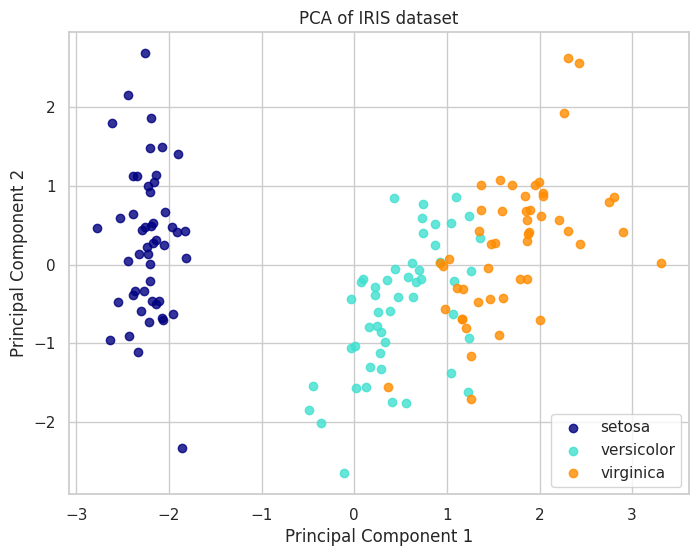

In [ ]:
#11 pca
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. Load Iris dataset (4 features: sepal length/width, petal length/width)
iris = load_iris()
X, y = iris.data, iris.target

# 2. Standardize (Crucial: Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA to reduce from 4D to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Analysis Output
print(f"Original shape: {X.shape}")
print(f"Reduced shape:  {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance retained:  {np.sum(pca.explained_variance_ratio_):.2%}")

# 5. Visualization
plt.figure(figsize=(8, 6))
colors = ['navy', 'turquoise', 'darkorange']
for i, color, name in zip([0, 1, 2], colors, iris.target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, alpha=.8, label=name)

plt.legend(loc='best')
plt.title('PCA of IRIS dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()